# Paper Figures
Loads experiment results and produces all figures for the extended abstract.

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from pathlib import Path
import scienceplots

plt.style.use('science')

OUT = Path("results/paper")
OUT.mkdir(exist_ok=True)

LANGS = {
    "da_dk": "Danish",
    "en_us": "English",
    "de_de": "German",
    "fr_fr": "French",
}
langs = list(LANGS.keys())

BLUE   = "#2166AC"
ORANGE = "#D6604D"
GREEN  = "#4DAC26"
GREY   = "#888888"

plt.rcParams.update({
    "font.size":          11,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "xtick.top":          False,
    "ytick.right":        False,
    "axes.titlesize":     12,
    "axes.labelsize":     11,
    "figure.dpi":         150,
    "pdf.fonttype":       42,
})


In [3]:
with open("results/delta_wers.json") as f:
    delta_data = json.load(f)

with open("results/prune_sweep_delta_wer.json") as f:
    sweep = json.load(f)

with open("results/distillation_log_5_6_7_9_11_12.json") as f:
    distlog = json.load(f)

with open("results/k7_zero_shot_sweep.json") as f:
    k7sweep = json.load(f)

with open("results/k6_random_baseline_sweep.json") as f:
    k6random = json.load(f)

with open("results/baseline_wers.json") as f:
    baseline_wers = json.load(f)

print("Data loaded.")
print(f"  delta_wers langs:  {list(delta_data['delta_wers'].keys())}")
print(f"  sweep steps:       {[s['k'] for s in sweep['steps']]}")
print(f"  distlog steps:     {[s['step'] for s in distlog['steps']]}")
print(f"  k7 candidates:     {[c['seventh_layer'] for c in k7sweep['candidates']]}")
print(f"  k6 random sets:    {len(k6random['random_sets'])}")

Data loaded.
  delta_wers langs:  ['da_dk', 'en_us', 'it_it', 'de_de', 'sv_se', 'fr_fr']
  sweep steps:       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  distlog steps:     [500, 1000, 1500, 2000]
  k7 candidates:     [10, 4, 13, 14, 8, 15, 20, 25, 2, 1]
  k6 random sets:    50


## Figure 1 — Layer importance heatmap

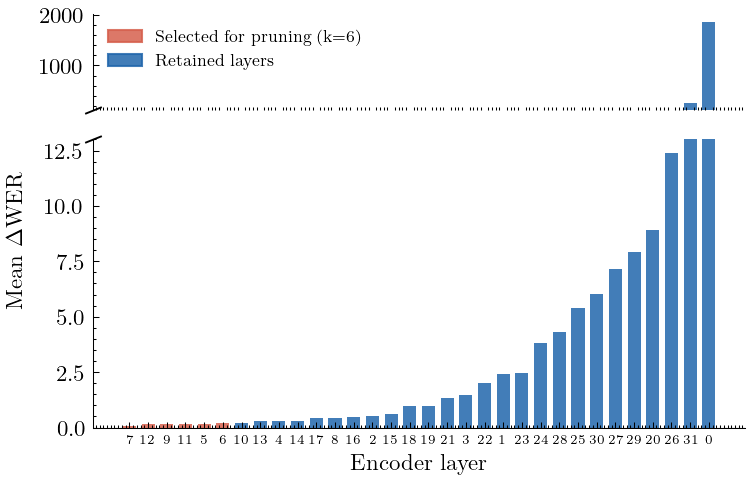

In [4]:

pruned_layers = set([5, 6, 7, 9, 11, 12])

n_layers = len(delta_data["delta_wers"][langs[0]])
mean_delta_pp = [
    np.mean([delta_data["delta_wers"][l][i] * 100 for l in langs])
    for i in range(n_layers)
]

order         = np.argsort(mean_delta_pp)
sorted_layers = [int(order[i]) for i in range(n_layers)]
sorted_values = [mean_delta_pp[order[i]] for i in range(n_layers)]
sorted_colors = [ORANGE if sorted_layers[i] in pruned_layers else BLUE
                 for i in range(n_layers)]

vals_desc = sorted(sorted_values, reverse=True)
high_min = vals_desc[1] * 0.80
high_max = vals_desc[0] * 1.08

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(5, 3.2),
    gridspec_kw={"height_ratios": [1, 3]},
    layout="constrained",
)
fig.get_layout_engine().set(hspace=0.04)

for ax in (ax_top, ax_bot):
    ax.bar(range(n_layers), sorted_values, color=sorted_colors, alpha=0.85, width=0.7)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.4)

ax_top.set_ylim(high_min-100, high_max)
ax_bot.set_ylim(0, 13)

ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False, labelbottom=False)

# Standard matplotlib broken-axis diagonal markers (see matplotlib broken_axis example).
# The marker [(-1,-d),(1,d)] draws a perfectly parallel slash regardless of aspect ratio.
d = 0.4
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=8,
              linestyle="none", color="k", mec="k", mew=0.9, clip_on=False)
ax_top.plot([0], [0], transform=ax_top.transAxes, **kwargs)
ax_bot.plot([0], [1], transform=ax_bot.transAxes, **kwargs)

ax_bot.set_xticks(range(n_layers))
ax_bot.set_xticklabels(sorted_layers, fontsize=6)
ax_bot.set_xlabel("Encoder layer")

fig.supylabel(r"Mean $\Delta$WER", fontsize=11)

ax_top.legend(handles=[Patch(color=ORANGE, alpha=0.85, label="Selected for pruning (k=6)"),
                        Patch(color=BLUE,   alpha=0.85, label="Retained layers")],
              frameon=False, fontsize=8)

fig.savefig(OUT / "fig1_layer_ranking.pdf", bbox_inches="tight")
fig.savefig(OUT / "fig1_layer_ranking.png", bbox_inches="tight")
plt.show()


In [5]:
# LaTeX table: top-12 ranked layers (the 6 pruned + 6 next), plus 2 high-importance anchors
show_layers = sorted_layers[:12] + [1, 0]   # bottom 12 + two important anchors

header = (
    r"\begin{table}[t]" "\n"
    r"    \centering" "\n"
    r"    \begin{tabular}{clrrrr}" "\n"
    r"    \toprule" "\n"
    r"    \textbf{Rank} & \textbf{Layer} & \textbf{Danish} & \textbf{English} "
    r"& \textbf{German} & \textbf{French} \\" "\n"
    r"    \midrule"
)
print(header)

for rank, layer in enumerate(show_layers, 1):
    per_lang = [delta_data["delta_wers"][l][layer] * 100 for l in langs]
    marker = r" $\leftarrow$ pruned" if layer in pruned_layers else ""
    sep = r"    \midrule" + "\n" if rank == 12 else ""
    row = (f"    {rank} & L{layer:2d} & "
           + " & ".join(f"{v:+.2f}" for v in per_lang)
           + r" \\" + marker)
    print(sep + row)

footer = (
    r"    \bottomrule" "\n"
    r"    \end{tabular}" "\n"
    r"    \caption{Layer importance ranking by mean $\Delta$WER (pp) when each layer "
    r"is removed in isolation. The six least important layers are selected for pruning.}" "\n"
    r"    \label{tab:layer_ranking}" "\n"
    r"\end{table}"
)
print(footer)

\begin{table}[t]
    \centering
    \begin{tabular}{clrrrr}
    \toprule
    \textbf{Rank} & \textbf{Layer} & \textbf{Danish} & \textbf{English} & \textbf{German} & \textbf{French} \\
    \midrule
    1 & L 7 & +0.08 & +0.00 & +0.11 & +0.14 \\ $\leftarrow$ pruned
    2 & L12 & +0.37 & +0.03 & -0.01 & +0.18 \\ $\leftarrow$ pruned
    3 & L 9 & +0.21 & -0.03 & +0.12 & +0.35 \\ $\leftarrow$ pruned
    4 & L11 & +0.32 & +0.12 & -0.04 & +0.29 \\ $\leftarrow$ pruned
    5 & L 5 & -0.08 & +0.01 & +0.58 & +0.20 \\ $\leftarrow$ pruned
    6 & L 6 & +0.27 & +0.05 & +0.09 & +0.34 \\ $\leftarrow$ pruned
    7 & L10 & +0.22 & +0.17 & +0.29 & +0.20 \\
    8 & L13 & +0.41 & +0.17 & +0.36 & +0.26 \\
    9 & L 4 & +0.51 & +0.13 & -0.04 & +0.62 \\
    10 & L14 & +0.52 & +0.04 & +0.42 & +0.28 \\
    11 & L17 & +0.74 & +0.40 & +0.24 & +0.29 \\
    \midrule
    12 & L 8 & +0.45 & +0.12 & +0.58 & +0.63 \\
    13 & L 1 & +4.20 & +1.16 & +1.14 & +3.09 \\
    14 & L 0 & +1819.12 & +2032.56 & +2035.76 & +1567.7

## Figure 2 — Pruning sweep + post-distillation recovery

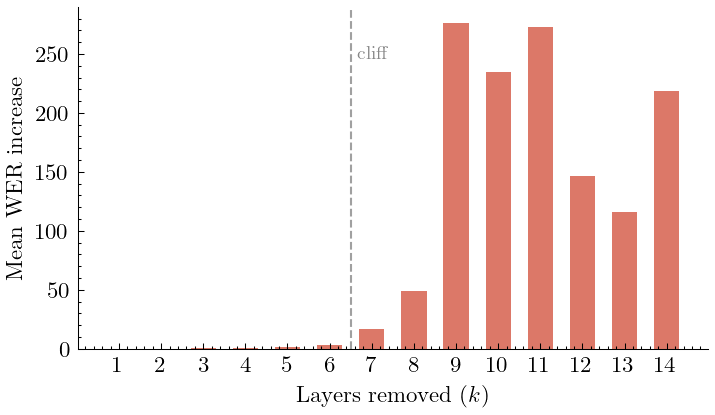

In [6]:
sweep_means_pp = [
    sum((s["wers"][l] - baseline_wers[l]) * 100 for l in langs if l in s["wers"]) /
    sum(1 for l in langs if l in s["wers"])
    for s in sweep["steps"]
]

ks = [s["k"] for s in sweep["steps"] if s["k"] > 0]
zs = [sweep_means_pp[i] for i, s in enumerate(sweep["steps"]) if s["k"] > 0]

fig, ax = plt.subplots(figsize=(5, 3))

ax.bar(ks, zs, width=0.6, color=ORANGE, alpha=0.85)

ax.axvline(6.5, color=GREY, linestyle="--", linewidth=1.0, alpha=0.8)
ax.text(6.65, ax.get_ylim()[1] * 0.85, "cliff", color=GREY, fontsize=9, style="italic")

ax.set_xlabel("Layers removed ($k$)")
ax.set_ylabel("Mean WER increase")
ax.set_xticks(ks)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 0 else f"{x:.1f}"))
ax.set_ylim(bottom=0)

fig.tight_layout()
fig.savefig(OUT / "fig2_pruning_sweep.pdf", bbox_inches="tight")
fig.savefig(OUT / "fig2_pruning_sweep.png", bbox_inches="tight")
plt.show()


## Figure 3 — Distillation recovery trajectory

<>:17: SyntaxWarning: invalid escape sequence '\%'
<>:21: SyntaxWarning: invalid escape sequence '\%'
<>:17: SyntaxWarning: invalid escape sequence '\%'
<>:21: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_2807819/2294529493.py:17: SyntaxWarning: invalid escape sequence '\%'
  ax.annotate(f"+{means[0]:.1f}\%",
/tmp/ipykernel_2807819/2294529493.py:21: SyntaxWarning: invalid escape sequence '\%'
  ax.annotate(f"+{means[-1]:.1f}\%",


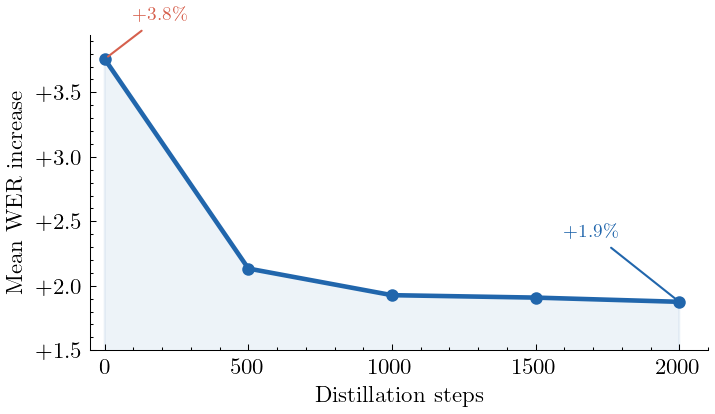

In [7]:
def mean_pp_over_langs(wer_dict):
    vals = [(v["wer"] - baseline_wers[lc]) * 100
            for lc, v in wer_dict.items() if lc in langs]
    if not vals:
        vals = [v["wer"] * 100 for v in wer_dict.values()]
    return sum(vals) / len(vals)

steps = [0] + [s["step"] for s in distlog["steps"]]
means = [mean_pp_over_langs(distlog["zero_shot"])] + \
        [mean_pp_over_langs(s["wer"]) for s in distlog["steps"]]

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(steps, means, color=BLUE, linewidth=2.2, marker="o", markersize=5, zorder=3)
ax.fill_between(steps, means, alpha=0.08, color=BLUE)

ax.annotate(f"+{means[0]:.1f}\%",
            xy=(steps[0], means[0]), xytext=(100, means[0] + 0.3),
            fontsize=9, color=ORANGE,
            arrowprops=dict(arrowstyle="-", color=ORANGE, lw=1.0))
ax.annotate(f"+{means[-1]:.1f}\%",
            xy=(steps[-1], means[-1]), xytext=(steps[-1] - 400, means[-1] + 0.5),
            fontsize=9, color=BLUE,
            arrowprops=dict(arrowstyle="-", color=BLUE, lw=1.0))

ax.axhline(0, color=GREY, linestyle=":", linewidth=1, alpha=0.5)
ax.set_xlabel("Distillation steps")
ax.set_ylabel("Mean WER increase")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"+{x:.1f}" if x >= 0 else f"{x:.1f}"))
ax.set_xlim(-50, steps[-1] + 100)
ax.set_ylim(bottom=1.5)

fig.tight_layout()
fig.savefig(OUT / "fig3_distillation_recovery.pdf", bbox_inches="tight")
fig.savefig(OUT / "fig3_distillation_recovery.png", bbox_inches="tight")
plt.show()


## Figure 4 — k=7 zero-shot sweep

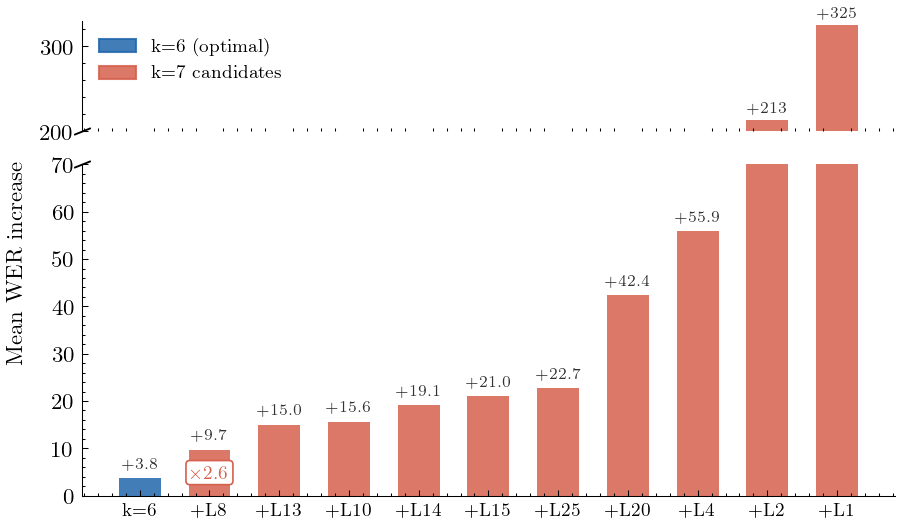

In [8]:
k6_pp = k7sweep["k6_reference"]["mean_delta_pp"]
candidates = sorted(k7sweep["candidates"], key=lambda x: x["mean_delta_pp"])

labels = ["k=6"] + [f"+L{c['seventh_layer']}" for c in candidates]
values = [k6_pp] + [c["mean_delta_pp"] for c in candidates]
colors = [BLUE] + [ORANGE] * len(candidates)

# Broken-axis limits
low_max  = 70
high_min = 200
high_max = 330

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(6, 3.5),
    gridspec_kw={"height_ratios": [1, 3]},
    layout="constrained",
)
fig.get_layout_engine().set(hspace=0.04)

for ax in (ax_top, ax_bot):
    ax.bar(range(len(labels)), values, color=colors, alpha=0.85, width=0.6)

ax_top.set_ylim(high_min, high_max)
ax_bot.set_ylim(0, low_max)

ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False, labelbottom=False)

# Standard matplotlib broken-axis diagonal markers
d = 0.4
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=8,
              linestyle="none", color="k", mec="k", mew=0.9, clip_on=False)
ax_top.plot([0], [0], transform=ax_top.transAxes, **kwargs)
ax_bot.plot([0], [1], transform=ax_bot.transAxes, **kwargs)

# Value labels: place each label just above its bar, in whichever panel it belongs to
label_pad_top = (high_max - high_min) * 0.04
label_pad_bot = low_max * 0.02
for i, val in enumerate(values):
    if val > low_max:
        y = min(val, high_max - label_pad_top) + label_pad_top
        ax_top.text(i, y, f"+{val:.0f}", ha="center", va="bottom",
                    fontsize=7.5, color="#333333")
    else:
        ax_bot.text(i, val + label_pad_bot, f"+{val:.1f}", ha="center", va="bottom",
                    fontsize=7.5, color="#333333")

# Annotate the ratio to best k=7
best_k7_pp = candidates[0]["mean_delta_pp"]
ratio = best_k7_pp / k6_pp
ax_bot.annotate(
    rf"$\times${ratio:.1f}",
    xy=(1, min(best_k7_pp, low_max) / 2),
    fontsize=9, color=ORANGE, ha="center", va="center",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=ORANGE, lw=0.8),
)

ax_bot.set_xticks(range(len(labels)))
ax_bot.set_xticklabels(labels, fontsize=9)
fig.supylabel("Mean WER increase", fontsize=11)

ax_top.legend(handles=[Patch(color=BLUE, alpha=0.85, label="k=6 (optimal)"),
                        Patch(color=ORANGE, alpha=0.85, label="k=7 candidates")],
              frameon=False, fontsize=9)

fig.savefig(OUT / "fig4_k7_sweep.pdf", bbox_inches="tight")
fig.savefig(OUT / "fig4_k7_sweep.png", bbox_inches="tight")
plt.show()


## Figure 5 — k=6 random baseline comparison

<>:18: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:26: SyntaxWarning: invalid escape sequence '\%'
<>:18: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:26: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_2807819/1648176469.py:18: SyntaxWarning: invalid escape sequence '\%'
  ax.annotate(f"+{opt_pp:.1f}\%",
/tmp/ipykernel_2807819/1648176469.py:23: SyntaxWarning: invalid escape sequence '\%'
  ax.annotate(f"+{random_pps[0]:.0f}\%",
/tmp/ipykernel_2807819/1648176469.py:26: SyntaxWarning: invalid escape sequence '\%'
  ax.annotate(f"+{random_pps[-1]:.0f}\%",


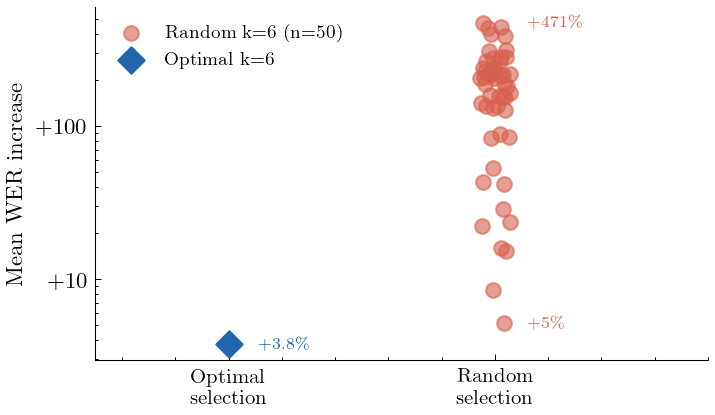

In [11]:
opt_pp     = k6random["optimal"]["mean_delta_pp"]
random_pps = sorted([r["mean_delta_pp"] for r in k6random["random_sets"]])

rng = np.random.default_rng(42)
jitter = rng.uniform(-0.06, 0.06, size=len(random_pps))

fig, ax = plt.subplots(figsize=(5, 3))


# Random samples as a strip on the right, optimal as a single point on the left
ax.scatter(1 + jitter, random_pps,
           color=ORANGE, s=50, zorder=3, alpha=0.6, label="Random k=6 (n=50)")
ax.scatter([0], [opt_pp],
           color=BLUE, s=80, zorder=4, marker="D", label="Optimal k=6")


# Annotate optimal value
ax.annotate(f"+{opt_pp:.1f}\%",
            xy=(0, opt_pp), xytext=(0.3, opt_pp),
            fontsize=8, color=BLUE, va="center", ha="right")

# Annotate best and worst random
ax.annotate(f"+{random_pps[0]:.0f}\%",
            xy=(1, random_pps[0]), xytext=(1.12, random_pps[0]),
            fontsize=8, color=ORANGE, va="center")
ax.annotate(f"+{random_pps[-1]:.0f}\%",
            xy=(1, random_pps[-1]), xytext=(1.12, random_pps[-1]),
            fontsize=8, color=ORANGE, va="center")

ax.set_yscale("log")
ax.set_ylabel("Mean WER increase")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Optimal\nselection", "Random\nselection"], fontsize=10)
ax.set_xlim(-0.5, 1.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"+{x:.0f}"))
ax.legend(frameon=False, fontsize=9, loc="upper left")

fig.tight_layout()
fig.savefig(OUT / "fig5_random_baseline.pdf", bbox_inches="tight")
fig.savefig(OUT / "fig5_random_baseline.png", bbox_inches="tight")
plt.show()
